## Import Library & Data

In [1]:
!pip install emoji transformers sentence-transformers scikit-learn pandas numpy matplotlib seaborn wordcloud imblearn faiss-cpu evaluate

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import requests
import csv
from io import StringIO
from wordcloud import WordCloud

from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

import random

import tensorflow as tf
from sentence_transformers import SentenceTransformer
import os

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'dana-app-sentiment-review-on-playstore-indonesia' dataset.
Path to dataset files: /kaggle/input/dana-app-sentiment-review-on-playstore-indonesia
['review_dana_labelled.csv']


In [5]:
csv_path = os.path.join(
    path,
    "review_dana_labelled.csv"
)

df = pd.read_csv(csv_path)
df.head()

,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  50000 non-null  object
 1   score     50000 non-null  int64 
 2   at        50000 non-null  object
 3   content   50000 non-null  object
 4   sentimen  50000 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


## Data Preprocessing

In [7]:
url = "https://raw.githubusercontent.com/ezaaputra/Sentiment-Analysis-Using-BERT/refs/heads/main/kamus_alay.csv"
slangwords = pd.read_csv(url)
slangwords.head()

,slang,formal
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [8]:
def casefoldingtext(text):
    text = text.lower()
    return text

def cleaningtext(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'(\w+)²', r'\1', text)
    text = re.sub(r'\b(\w+)\1\b', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = " ".join([w for w in text.split() if len(w) > 1])
    text = emoji.demojize(text)
    text = re.sub(':[A-Za-z_-]+:', ' ', text)
    text = re.sub(r"([xX;:]'?[dDpPvVoO3)(])", ' ', text)
    text = text.replace('\n', '')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

normalize_word_dict = {}

for _, row in slangwords.iterrows():
    normalize_word_dict[row[0]] = row[1]

def fix_slangwords(text):
    words = word_tokenize(text)

    words = [
        normalize_word_dict[word]
        if word in normalize_word_dict
        else word
        for word in words
    ]

    return " ".join(words)

/tmp/ipykernel_7072/3717972429.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalize_word_dict[row[0]] = row[1]


In [9]:
teks = "  akuuuu mau      memberi makan gaga tidak berguna      "
tokens = word_tokenize(teks)
print(cleaningtext(teks))

aku mau memberi makan ga tidak berguna


In [10]:
df['text_casefolding'] = df['content'].apply(casefoldingtext)

df['text_clean'] = df['text_casefolding'].apply(cleaningtext)

df['text_final'] = df['text_clean'].apply(fix_slangwords)

In [11]:
df.head()

,userName,score,at,content,sentimen,text_casefolding,text_clean,text_final
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE,bagus,bagus,bagus
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE,dana mmg keren mantap.,dana mmg keren mantap,dana memang keren mantap
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE,saya ngajuin upgrade dana premium krna ktp say...,saya ngajuin upgrade dana premium krna ktp say...,saya mengajukan upgrade dana premium karena kt...
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE,kocak mana diskon nya ml malah eror segala kag...,kocak mana diskon nya ml malah eror segala kag...,kocak mana diskon nya ml malah eror segala kag...
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE,saldo hilang karena no lama hilang ganti no sa...,saldo hilang karena no lama hilang ganti no sa...,saldo hilang karena no lama hilang ganti no sa...


In [12]:
df.to_csv("Clean DataSet Review App Spotify.csv", index=False)

## EDA

In [13]:
df['sentimen'].value_counts()

,count
sentimen,
POSITIVE,26555
NEGATIVE,17073
NEUTRAL,6372


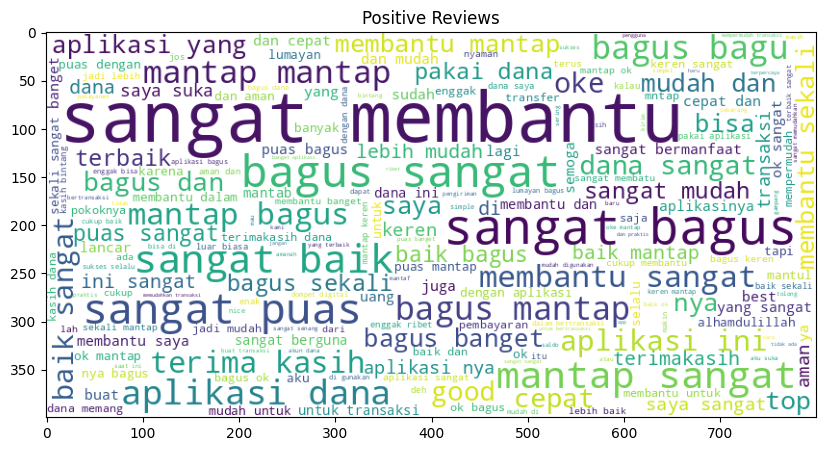

In [14]:
positive_text = " ".join(
    df[df['sentimen'] == 'POSITIVE']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('Positive Reviews')
plt.show()

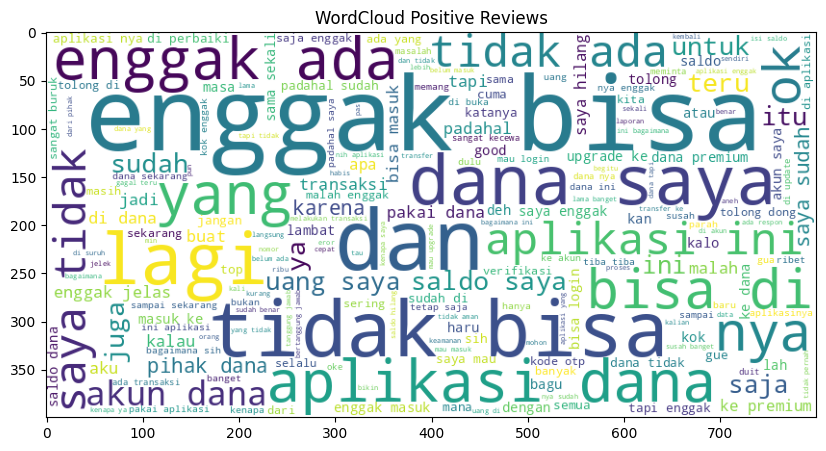

In [15]:
positive_text = " ".join(
    df[df['sentimen'] == 'NEGATIVE']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('WordCloud Positive Reviews')
plt.show()

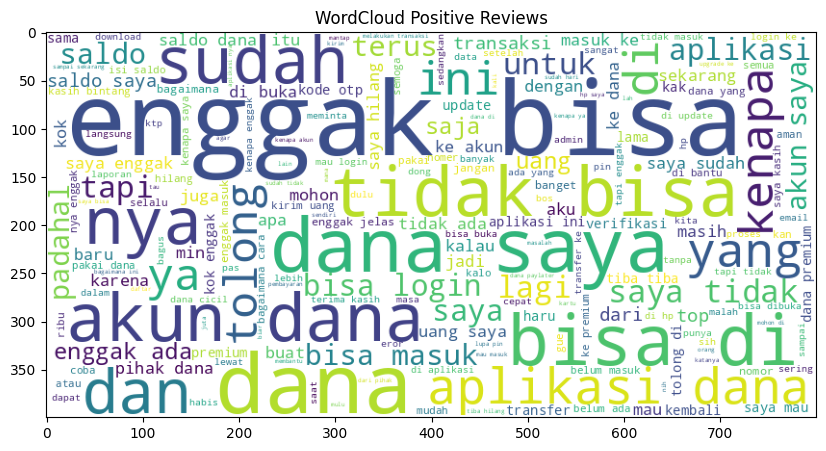

In [16]:
positive_text = " ".join(
    df[df['sentimen'] == 'NEUTRAL']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('WordCloud Positive Reviews')
plt.show()

## Data Spliting

In [18]:
X = df["text_final"]
y = df["sentimen"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Undersampling

In [21]:
undersampler = RandomUnderSampler(random_state=42)
X, y = undersampler.fit_resample(X_train.to_frame(), y_train)
X_train = X_train.squeeze()

In [22]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)

y_test = le.transform(y_test)

In [47]:
print(dict(zip(
    le.classes_,
    le.transform(le.classes_)
)))

{'NEGATIVE': np.int64(0), 'NEUTRAL': np.int64(1), 'POSITIVE': np.int64(2)}


In [46]:
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{'NEGATIVE': np.int64(5098), 'NEUTRAL': np.int64(5098), 'POSITIVE': np.int64(5098)}


## Build Model Sentence Transformer


In [23]:
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

X_train_emb = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_emb = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [48]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_emb.shape[1],)),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
history = model.fit(
    X_train_emb,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7861 - loss: 0.5227 - val_accuracy: 0.8170 - val_loss: 0.4596
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8083 - loss: 0.4631 - val_accuracy: 0.8148 - val_loss: 0.4516
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8151 - loss: 0.4482 - val_accuracy: 0.8173 - val_loss: 0.4389
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8187 - loss: 0.4393 - val_accuracy: 0.8250 - val_loss: 0.4407
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8211 - loss: 0.4303 - val_accuracy: 0.8120 - val_loss: 0.4411
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8240 - loss: 0.4246 - val_accuracy: 0.8335 - val_loss: 0.4395
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8256 - loss: 0.4165 - val_accuracy: 0.8275 - val_loss: 0.4337
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8321 - loss: 0.4079 -

In [50]:
test_loss, test_acc = model.evaluate(
    X_test_emb,
    y_test
)

print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8206 - loss: 0.4474
Accuracy: 0.8205999732017517


In [51]:
y_pred = model.predict(X_test_emb)

y_pred_class = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [52]:
print(
    classification_report(
        y_test,
        y_pred_class,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

    NEGATIVE       0.75      0.85      0.80      3415
     NEUTRAL       0.62      0.39      0.48      1274
    POSITIVE       0.90      0.90      0.90      5311

    accuracy                           0.82     10000
   macro avg       0.76      0.71      0.73     10000
weighted avg       0.81      0.82      0.81     10000



In [32]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(
    n_neighbors=5,
    metric='cosine'
)

nn.fit(X_train_emb)

NearestNeighbors(metric='cosine')

In [33]:
query = "aplikasi dana sering error saat transfer"

query_emb = embedding_model.encode([query])

distances, indices = nn.kneighbors(query_emb)

In [34]:
for idx in indices[0]:
    print(X_train.iloc[idx])

transfer sering gagal
akhir akhir ini aplikasi nya jadi sering error kalo mau transfer jadi harus hapus data aplikasi dana nya baru bisa transfer tolong perbaiki masalah ini
banyak error seperti tarik tunai maupun transfer ke bank dan dari bank ke dana sendiri
aplikasi tidak aman saldo tiba tiba hilang ter transfer padahal tidak merasa transfer ke dana lain pengaman kurang aman
sering eror gagal transfermohon di perbaiki


In [35]:
sample = "aplikasi sangat membantu dan mudah digunakan"

sample_emb = embedding_model.encode([sample])

pred = model.predict(sample_emb)

label = le.inverse_transform(
    [np.argmax(pred)]
)[0]

print("Review :", sample)
print("Prediksi :", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
Review : aplikasi sangat membantu dan mudah digunakan
Prediksi : POSITIVE


## Build Model IndoBERT

In [36]:
from transformers import AutoTokenizer
from transformers import TFAutoModelForSequenceClassification

ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [37]:
import transformers
import tensorflow as tf

print(transformers.__version__)
print(tf.__version__)

5.0.0
2.20.0


In [38]:
print(hasattr(transformers, "TFAutoModelForSequenceClassification"))

False
